In [1]:
import numpy as np
import pandas as pd
from utils.model_training import prepare_model_features
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# Deep Learning Introduction
Its been a long road to this point and I refer you to the introduction in the first notebook for more context, but tl;dr this notebook is an attempt to model the use of violence by the police during stop and frisk interactions.

All of the data comes from the NYPD itself via its published yearly data on NYC's open data website.  The bulk of EDA is in the second notebook.  This notebook is dedicated to building upon the (imho) inadequate results from earlier modeling to determine if a neural net can generalize better than its less complex model peers.

# (Where's the) EDA
For the sake of time and keeping things DRY, I will simply import the cleaned and prepared data, but a robust EDA writeup can be found in the [second notebook](./2.%20Exploratory%20Data%20Analysis.ipynb).

In [2]:
df = pd.read_csv(
    "./data/processed/stop-and-frisk.csv",
    parse_dates=["STOP_FRISK_DATE"],  
)

X, y = prepare_model_features(df)
assert not X.isnull().any().any(), "Null values remain in features"

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print("Train distribution:", y_train.value_counts(normalize=True), "\n")
print("Test distribution:", y_test.value_counts(normalize=True))

Train distribution: OFFICER_USED_FORCE
False    0.748507
True     0.251493
Name: proportion, dtype: float64 

Test distribution: OFFICER_USED_FORCE
False    0.748501
True     0.251499
Name: proportion, dtype: float64


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import pandas as pd

class NYPDForcePredictor(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64, 32], dropout_rate=0.3):
        super(NYPDForcePredictor, self).__init__()
        
        # Build the network layers
        layers = []
        
        # Input layer
        layers.append(nn.Linear(input_size, hidden_sizes[0]))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm1d(hidden_sizes[0]))
        layers.append(nn.Dropout(dropout_rate))
        
        # Hidden layers
        for i in range(len(hidden_sizes) - 1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_sizes[i + 1]))
            layers.append(nn.Dropout(dropout_rate))
        
        # Output layer
        layers.append(nn.Linear(hidden_sizes[-1], 1))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

class NYPDModelTrainer:
    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.device = device
        self.scaler = StandardScaler()
        
    def prepare_data(self, X, y, test_size=0.2, batch_size=512):
        """Prepare and scale the data for training"""
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Convert to tensors
        X_train_tensor = torch.FloatTensor(X_train_scaled)
        X_test_tensor = torch.FloatTensor(X_test_scaled)
        y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
        y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)
        
        # Create data loaders
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        return train_loader, test_loader, X_test_tensor, y_test_tensor
    
    def train(self, train_loader, test_loader, epochs=100, lr=0.001, weight_decay=1e-5, class_weighting=3.0, verbose=False):
        """Train the model with class weighting for imbalanced data"""
        # Calculate class weights (since force usage is 25% minority)
        pos_weight = torch.tensor([class_weighting]).to(self.device)  # 3.0 represents the 75/25 ratio underlying the class balances
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
        # Use the model without final sigmoid for BCEWithLogitsLoss
        self.model.network = self.model.network[:-1]  # Remove sigmoid
        
        optimizer = optim.Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
        
        train_losses = []
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            # Training phase
            self.model.train()
            train_loss = 0.0
            
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
            
            # Validation phase
            self.model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                    outputs = self.model(batch_X)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()
            
            train_loss /= len(train_loader)
            val_loss /= len(test_loader)
            train_losses.append(train_loss)
            
            scheduler.step(val_loss)
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Save best model
                torch.save(self.model.state_dict(), 'best_nn_nypd_model.pth')
            else:
                patience_counter += 1
                
            if patience_counter >= 15:
                print(f"Early stopping at epoch {epoch}")
                break
            
            if verbose and epoch % 10 == 0:
                print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        # Load best model
        self.model.load_state_dict(torch.load('best_nn_nypd_model.pth'))
        
        # Add sigmoid back for predictions
        self.model.network = nn.Sequential(self.model.network, nn.Sigmoid())
        
        return train_losses
    
    def evaluate(self, X_test, y_test, verbose=False):
        """Evaluate the model and return metrics"""
        self.model.eval()
        
        with torch.no_grad():
            X_test = X_test.to(self.device)
            y_pred_proba = self.model(X_test).cpu().numpy()
            y_pred = (y_pred_proba > 0.5).astype(int)
        
        y_true = y_test.cpu().numpy()
        
        # Calculate metrics
        auc_score = roc_auc_score(y_true, y_pred_proba)
        
        if verbose:
            print("Classification Report:")
            print(classification_report(y_true, y_pred))
            print(f"\nAUC Score: {auc_score:.4f}")
            print("\nConfusion Matrix:")
            print(confusion_matrix(y_true, y_pred))
        
        return {
            'auc': auc_score,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }

# Usage Example:
def run_nypd_force_model(X, y, architecture_params=None, name="Unknown", verbose=False):
    """
    Main function to run the NYPD force prediction model
    X, y should come from your prepare_model_features() function
    """
    default_params = {
        'hidden_sizes': [128, 64, 32],
        'dropout_rate': 0.3,
        'class_weighting': 3.0,
        'lr': 0.001
    }
    
    # Merge with provided parameters
    if architecture_params is None:
        architecture_params = {}
    
    params = {**default_params, **architecture_params}

    # Initialize model
    input_size = X.shape[1]
    model = NYPDForcePredictor(
        input_size=input_size,
        hidden_sizes=params['hidden_sizes'],
        dropout_rate=params['dropout_rate'],
    )
    
    # Initialize trainer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainer = NYPDModelTrainer(model, device)
    
    print(f"Using model: {name}")
    print(f"Using device: {device}")
    print(f"Input features: {input_size}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Prepare data
    train_loader, test_loader, X_test, y_test = trainer.prepare_data(X, y)
    
    # Train model
    print(f"\nStarting training on {name}...")
    train_losses = trainer.train(train_loader, test_loader, epochs=100, class_weighting=params['class_weighting'], lr=params['lr'])
    
    # Evaluate model
    verbose and print("\nEvaluating model...")
    results = trainer.evaluate(X_test, y_test)
    
    # Store y_true for comparison
    results['y_true'] = y_test.cpu().numpy().flatten()
    
    return trainer, results



In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

class ModelComparison:
    def __init__(self):
        self.results = {}
    
    def add_result(self, model_name, results_dict):
        """Add results from run_nypd_force_model to comparison"""
        self.results[model_name] = results_dict
        print(f"Added {model_name}: AUC = {results_dict['auc']:.3f}")
    
    def plot_comparison(self, figsize=(15, 5)):
        """Plot comparison of all tracked models"""
        if len(self.results) < 2:
            print("Need at least 2 models to compare")
            return
            
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # Collect metrics
        metrics_data = []
        
        # 1. ROC Curves
        for model_name, results in self.results.items():
            # Get stored probabilities and true labels
            y_pred_proba = results['probabilities']
            # We need to reconstruct y_true from the trainer that called this
            # For now, we'll use a workaround
            fpr, tpr, _ = roc_curve(results.get('y_true', []), y_pred_proba)
            auc = results['auc']
            axes[0].plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', linewidth=2)
            
            # Calculate other metrics from stored predictions
            y_pred = results['predictions']
            y_true = results.get('y_true', [])
            
            if len(y_true) > 0:  # If y_true is available
                precision = precision_score(y_true, y_pred)
                recall = recall_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred)
                accuracy = accuracy_score(y_true, y_pred)
            else:
                # Fallback values if y_true not stored
                precision = recall = f1 = accuracy = 0.0
            
            metrics_data.append({
                'Model': model_name,
                'AUC': auc,
                'Precision': precision,
                'Recall': recall,
                'F1': f1,
                'Accuracy': accuracy
            })
        
        axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].set_title('ROC Curves')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # 2. Metrics Comparison Bar Chart
        df_metrics = pd.DataFrame(metrics_data)
        metrics_to_plot = ['AUC', 'Precision', 'Recall', 'F1']
        
        x = np.arange(len(df_metrics))
        width = 0.2
        
        for i, metric in enumerate(metrics_to_plot):
            axes[1].bar(x + i*width, df_metrics[metric], width, 
                       label=metric, alpha=0.8)
        
        axes[1].set_xlabel('Models')
        axes[1].set_ylabel('Score')
        axes[1].set_title('Performance Metrics')
        axes[1].set_xticks(x + width * 1.5)
        axes[1].set_xticklabels(df_metrics['Model'], rotation=45)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig, df_metrics
    
    def plot_summary_table(self, figsize=(15, 5)):
        if len(self.results) < 2:
            print("Need at least 2 models to compare")
            return
            
        fig, axes = plt.subplots(1, 1, figsize=figsize)
        
        # Collect metrics
        metrics_data = []
        
        # 1. ROC Curves
        for model_name, results in self.results.items():
            # Get stored probabilities and true labels
            y_pred_proba = results['probabilities']
            # We need to reconstruct y_true from the trainer that called this
            # For now, we'll use a workaround
            fpr, tpr, _ = roc_curve(results.get('y_true', []), y_pred_proba)
            auc = results['auc']
            # axes.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', linewidth=2)
            
            # Calculate other metrics from stored predictions
            y_pred = results['predictions']
            y_true = results.get('y_true', [])
            
            if len(y_true) > 0:  # If y_true is available
                precision = precision_score(y_true, y_pred)
                recall = recall_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred)
                accuracy = accuracy_score(y_true, y_pred)
            else:
                # Fallback values if y_true not stored
                precision = recall = f1 = accuracy = 0.0
            
            metrics_data.append({
                'Model': model_name,
                'AUC': auc,
                'Precision': precision,
                'Recall': recall,
                'F1': f1,
                'Accuracy': accuracy
            })
        df_metrics = pd.DataFrame(metrics_data)
        
        axes.axis('tight')
        axes.axis('off')
        
        display_df = df_metrics.round(3)
        table = axes.table(cellText=display_df.values,
                             colLabels=display_df.columns,
                             cellLoc='center',
                             loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.5)
        
        axes.set_title('Performance Summary')
        plt.tight_layout()
        
    
    def print_summary(self):
        """Print a quick summary of all models"""
        print("\n" + "="*50)
        print("MODEL PERFORMANCE SUMMARY")
        print("="*50)
        
        for model_name, results in self.results.items():
            print(f"{model_name:20s} | AUC: {results['auc']:.3f}")
        
        best_model = max(self.results.items(), key=lambda x: x[1]['auc'])
        print("-"*50)
        print(f"Best Model: {best_model[0]} (AUC: {best_model[1]['auc']:.3f})")

def experiment_with_architectures(X, y):
    """
    Example of how to compare different model configurations
    """
    comparison = ModelComparison()
    
    # Test different architectures
    architectures = {
        'Small Network': {
            'hidden_sizes': [64, 32],
            'dropout_rate': 0.3,
            'lr': 0.001,
            'class_weighting': 3.0
        },
        'Medium Network': {
            'hidden_sizes': [128, 64, 32],
            'dropout_rate': 0.3,
            'lr': 0.001,
            'class_weighting': 3.0
        },
        'Large Network': {
            'hidden_sizes': [256, 128, 64],
            'dropout_rate': 0.3,
            'lr': 0.001,
            'class_weighting': 3.0
        },
        'High Dropout': {
            'hidden_sizes': [128, 64, 32],
            'dropout_rate': 0.5,
            'lr': 0.001,
            'class_weighting': 3.0
        },
        'Lower LR': {
            'hidden_sizes': [128, 64, 32],
            'dropout_rate': 0.3,
            'lr': 0.0005,
            'class_weighting': 3.0
        },
        'High LR': {
            'hidden_sizes': [128, 64, 32],
            'dropout_rate': 0.3,
            'lr': 0.05,
            'class_weighting': 3.0
        },
        'Balanced Weighting': {
            'hidden_sizes': [128, 64, 32],
            'dropout_rate': 0.3,
            'lr': 0.001,
            'class_weighting': 2.0
        },
        'Majority Weighting': {
            'hidden_sizes': [128, 64, 32],
            'dropout_rate': 0.3,
            'lr': 0.001,
            'class_weighting': 1.0
        }
    }
    
    for name, arch in architectures.items():
        trainer, results = run_nypd_force_model(X, y, arch, name=name)
        comparison.add_result(name, results)
    
    # Plot comparison
    # fig, metrics_df = comparison.plot_comparison()
    # comparison.plot_comparison()
    # comparison.print_summary()
    
    return comparison



# Model Training
I will train a variety of basic NN architectures varying across different hyperparameters for the hidden layer architecture as well as typical parameters (learning rate, dropout rate, etc.)

In [5]:
comparison = experiment_with_architectures(X, y)
# comparison.print_summary()

Using model: Small Network
Using device: cuda
Input features: 26
Model parameters: 4,033

Starting training on Small Network...
Early stopping at epoch 49
Added Small Network: AUC = 0.664
Using model: Medium Network
Using device: cuda
Input features: 26
Model parameters: 14,273

Starting training on Medium Network...
Early stopping at epoch 40
Added Medium Network: AUC = 0.663
Using model: Large Network
Using device: cuda
Input features: 26
Model parameters: 49,025

Starting training on Large Network...
Early stopping at epoch 30
Added Large Network: AUC = 0.664
Using model: High Dropout
Using device: cuda
Input features: 26
Model parameters: 14,273

Starting training on High Dropout...
Early stopping at epoch 69
Added High Dropout: AUC = 0.661
Using model: Lower LR
Using device: cuda
Input features: 26
Model parameters: 14,273

Starting training on Lower LR...
Early stopping at epoch 56
Added Lower LR: AUC = 0.663
Using model: High LR
Using device: cuda
Input features: 26
Model parame

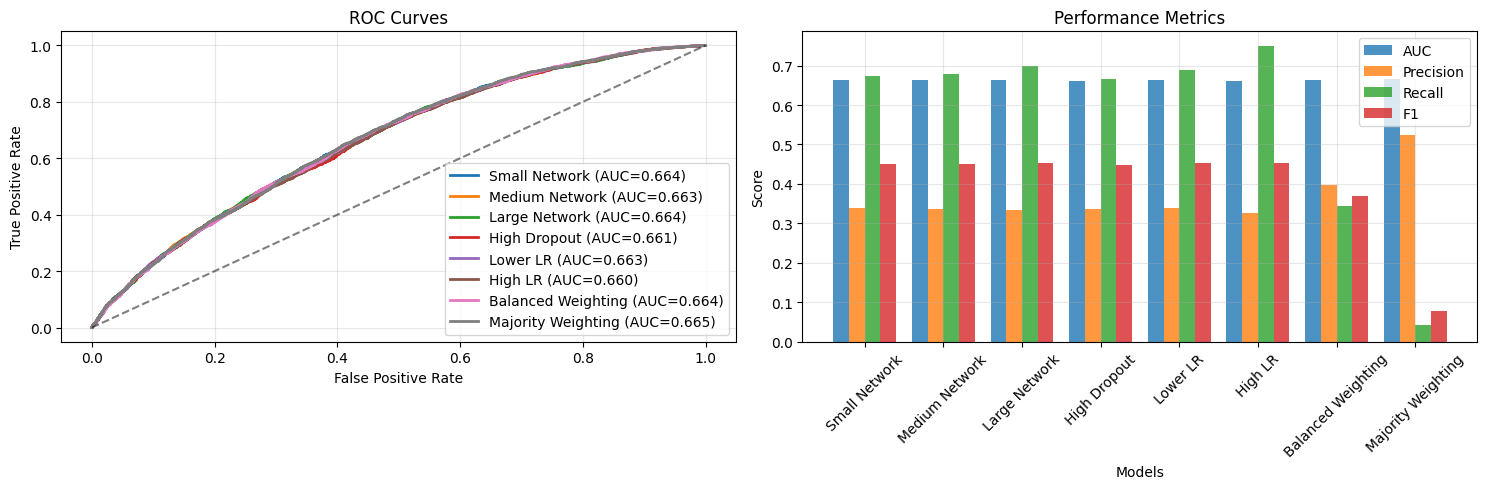

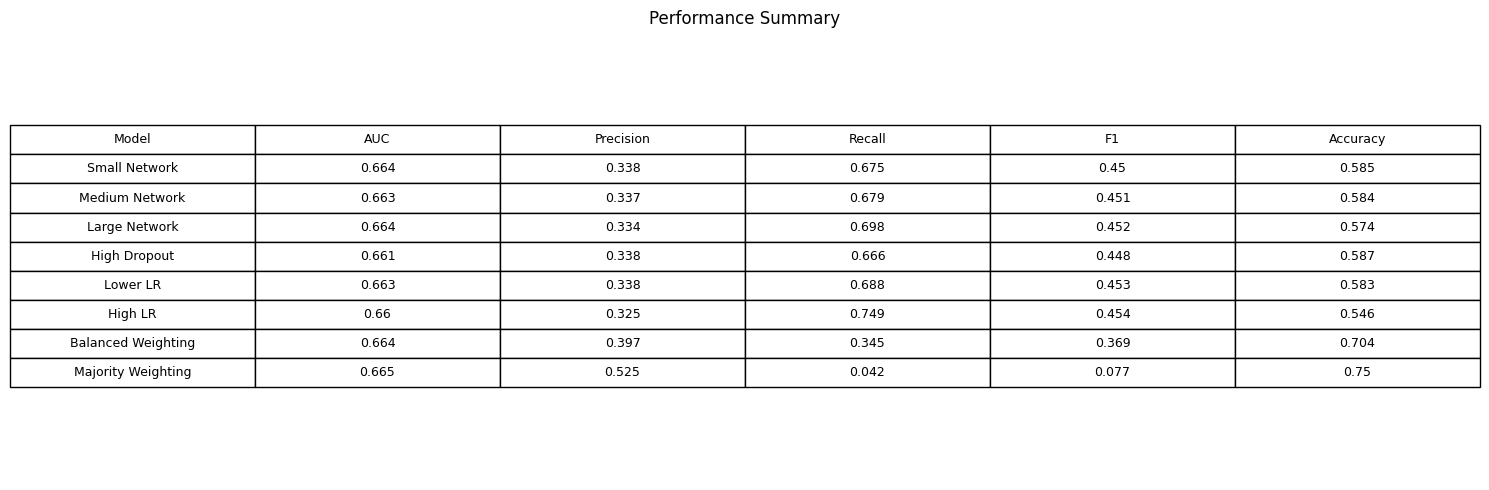

In [6]:
comparison.plot_comparison()
comparison.plot_summary_table()

## Hyperparameter juicing is of little effect
Starting with a general foundation of hidden layer dimensions of [128,64,32], I tried doubling and halving the hidden dimensions to no general improvement of the model.  Similarly, increasing the dropout rate to .5/50% didn't improve the model, but did increase training time as expected.  

### Juicing moderately works
Tl;dr, increasing the hidden dimensions, increasing the dropout rate to 50%, decreasing the class imbalance weighting from 3.0 -> 2.5, and a 50x increase in learning rate from 0.001 -> 0.05 improved overall accuracy ~58% -> 64%. 

All of these results aren't markedly better than the linear supervised models that I initially trained, with top accuracy reaching ~70%, though both models only achieve this accuracy by overfitting the majority class. 

## Standing on the shoulders of giants (i.e. myself)
Though I didn't get fully improved results via unsupervised learning, I did pull out a new feature which did help model performance.  I will pull that in here. TBD.

In [7]:
# Very hacky and temporary....
pca_X = pd.read_csv(
    "./data/processed/pca_X.csv",
).iloc[:, 1:]

pca_y = pd.read_csv(
    "./data/processed/pca_y.csv",
)["OFFICER_USED_FORCE"]


Using model: Small Network
Using device: cuda
Input features: 27
Model parameters: 4,097

Starting training on Small Network...
Early stopping at epoch 50
Added Small Network: AUC = 0.665
Using model: Medium Network
Using device: cuda
Input features: 27
Model parameters: 14,401

Starting training on Medium Network...
Early stopping at epoch 47
Added Medium Network: AUC = 0.664
Using model: Large Network
Using device: cuda
Input features: 27
Model parameters: 49,281

Starting training on Large Network...
Early stopping at epoch 37
Added Large Network: AUC = 0.665
Using model: High Dropout
Using device: cuda
Input features: 27
Model parameters: 14,401

Starting training on High Dropout...
Added High Dropout: AUC = 0.664
Using model: Lower LR
Using device: cuda
Input features: 27
Model parameters: 14,401

Starting training on Lower LR...
Early stopping at epoch 50
Added Lower LR: AUC = 0.662
Using model: High LR
Using device: cuda
Input features: 27
Model parameters: 14,401

Starting trai

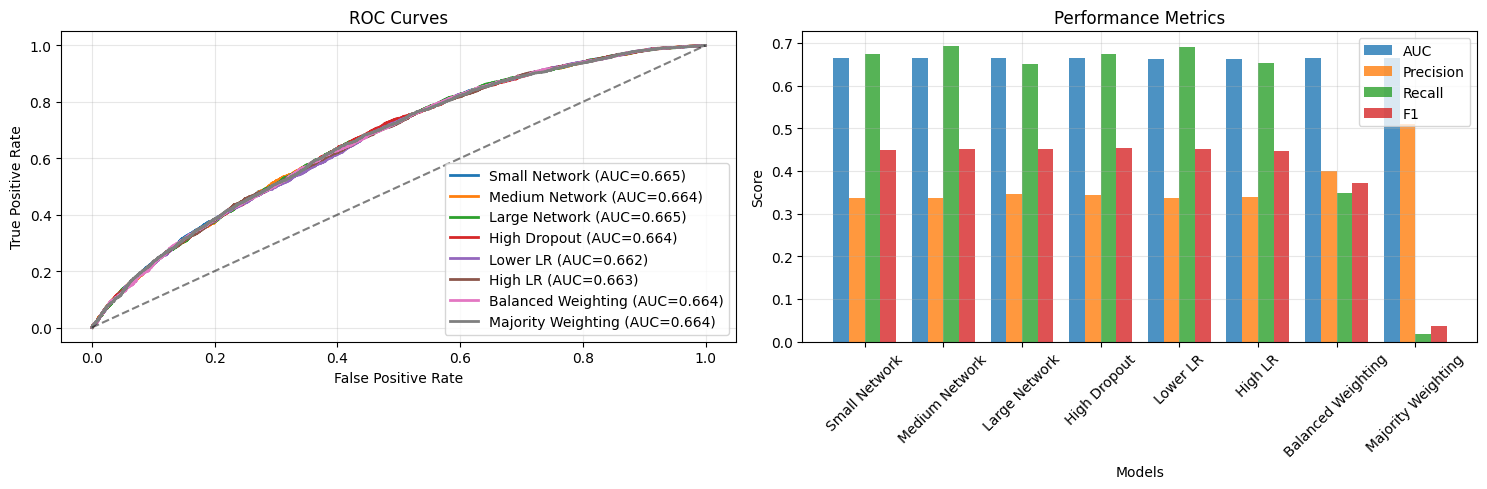

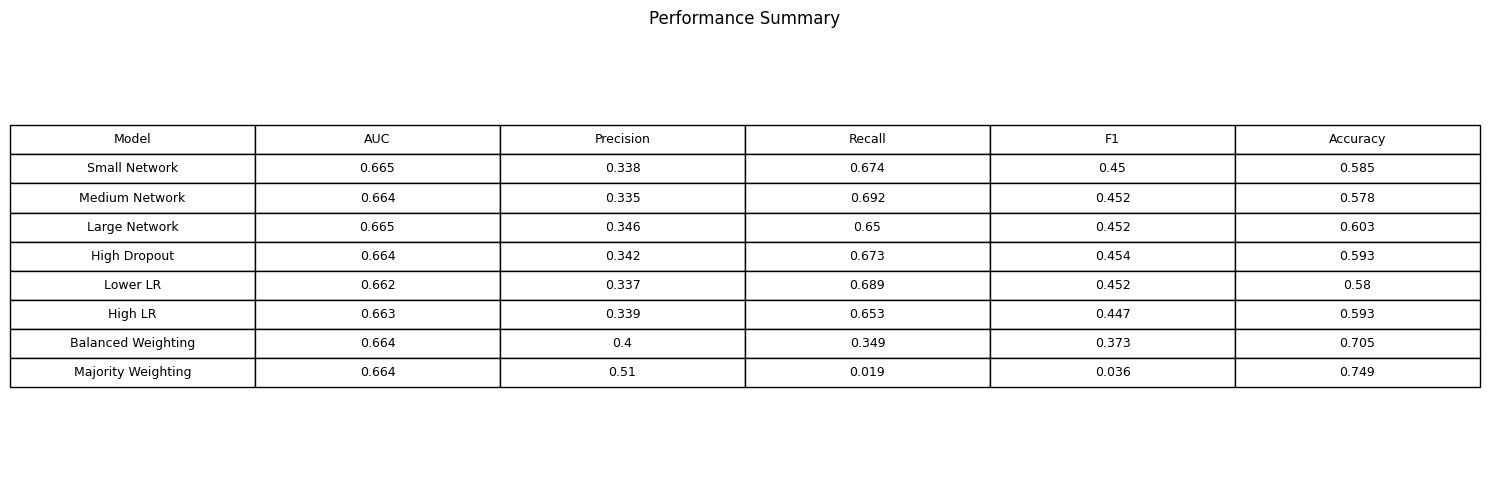

In [8]:
comparison = experiment_with_architectures(pca_X, pca_y)
comparison.plot_comparison()
comparison.plot_summary_table()

### Or Maybe Not
No significant improvement in model performance with the unsupervised learning augmentation :( 

# Results + Conclusions
"Modelling is hard" - Zoolander 

Less flippantly, I really expected neural net architectures to generalize much better to be honest.  The overall model performance mirrored supervised models at best, but with far more computation.  

The only significant benefit is that given neural nets are better equipped to handle higher dimensional data, I was able to confirm that the earlier models were not bottlenecked by the inclusion of too many features.

Regardless, I will continue this research until I get to a place where I can state some positive results.  
## Next steps 
- feature engineering given that seems to be the major hurdle after the failure of these various models.
- experimenting with other deep neural net architectures
- integrating SHAP analysis for more feature auditing